In [45]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [46]:
df = pd.read_csv("../data/processed/churn_modeling_dataset.csv")

X = df.drop(columns=["Churn Value"])
y = df["Churn Value"]

print("Dataset:", df.shape)
print("Features:", X.shape)
print("Target:", y.shape)

Dataset: (7043, 23)
Features: (7043, 22)
Target: (7043,)


In [47]:
# First split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Second split: divide the temporary data equally
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [48]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTraining churn proportions:")
print(y_train.value_counts(normalize=True))

print("\nValidation churn proportions:")
print(y_val.value_counts(normalize=True))

print("\nTest churn proportions:")
print(y_test.value_counts(normalize=True))

Training: (4930, 22)
Validation: (1056, 22)
Test: (1057, 22)

Training churn proportions:
Churn Value
0    0.734686
1    0.265314
Name: proportion, dtype: float64

Validation churn proportions:
Churn Value
0    0.734848
1    0.265152
Name: proportion, dtype: float64

Test churn proportions:
Churn Value
0    0.734153
1    0.265847
Name: proportion, dtype: float64


In [49]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_val_pred = baseline.predict(X_val)

print("Baseline Accuracy:", accuracy_score(y_val, baseline_val_pred))
print("Baseline Recall:", recall_score(y_val, baseline_val_pred, zero_division=0))
print("Baseline F1:", f1_score(y_val, baseline_val_pred, zero_division=0))

Baseline Accuracy: 0.7348484848484849
Baseline Recall: 0.0
Baseline F1: 0.0


In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Identify numerical and categorical features
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()
categorical_cols = [
    col for col in X_train.columns
    if col not in numeric_cols
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        )
    ]
)

# Complete ML pipeline
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

# Train using training data only
pipeline.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

val_pred = pipeline.predict(X_val)
val_proba = pipeline.predict_proba(X_val)[:, 1]

print("Accuracy:", accuracy_score(y_val, val_pred))
print("Precision:", precision_score(y_val, val_pred, zero_division=0))
print("Recall:", recall_score(y_val, val_pred, zero_division=0))
print("F1 Score:", f1_score(y_val, val_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_val, val_proba))
print("PR-AUC:", average_precision_score(y_val, val_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_pred))

Accuracy: 0.8058712121212122
Precision: 0.6447876447876448
Recall: 0.5964285714285714
F1 Score: 0.6196660482374768
ROC-AUC: 0.8508100147275406
PR-AUC: 0.6380506049760285

Confusion Matrix:
[[684  92]
 [113 167]]


In [52]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import clone

tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

tree_pipeline.fit(X_train, y_train)

print("Decision Tree training completed.")

Decision Tree training completed.


In [53]:
tree_train_pred = tree_pipeline.predict(X_train)
tree_val_pred = tree_pipeline.predict(X_val)
tree_val_proba = tree_pipeline.predict_proba(X_val)[:, 1]

print("Training Accuracy:", accuracy_score(y_train, tree_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, tree_val_pred))
print("Validation Precision:", precision_score(y_val, tree_val_pred, zero_division=0))
print("Validation Recall:", recall_score(y_val, tree_val_pred, zero_division=0))
print("Validation F1:", f1_score(y_val, tree_val_pred, zero_division=0))
print("Validation ROC-AUC:", roc_auc_score(y_val, tree_val_proba))
print("Validation PR-AUC:", average_precision_score(y_val, tree_val_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, tree_val_pred))

Training Accuracy: 1.0
Validation Accuracy: 0.7178030303030303
Validation Precision: 0.47019867549668876
Validation Recall: 0.5071428571428571
Validation F1: 0.4879725085910653
Validation ROC-AUC: 0.6504786450662741
Validation PR-AUC: 0.36913971789799604

Confusion Matrix:
[[616 160]
 [138 142]]


The Decision Tree is overfitting: training accuracy is 100%, but validation accuracy is only 71.78%.

### Training Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [55]:
rf_train_pred = rf_pipeline.predict(X_train)
rf_val_pred = rf_pipeline.predict(X_val)
rf_val_proba = rf_pipeline.predict_proba(X_val)[:, 1]

print("Training Accuracy:", accuracy_score(y_train, rf_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, rf_val_pred))
print("Validation Precision:", precision_score(y_val, rf_val_pred, zero_division=0))
print("Validation Recall:", recall_score(y_val, rf_val_pred, zero_division=0))
print("Validation F1:", f1_score(y_val, rf_val_pred, zero_division=0))
print("Validation ROC-AUC:", roc_auc_score(y_val, rf_val_proba))
print("Validation PR-AUC:", average_precision_score(y_val, rf_val_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, rf_val_pred))

Training Accuracy: 1.0
Validation Accuracy: 0.7821969696969697
Validation Precision: 0.6059322033898306
Validation Recall: 0.5107142857142857
Validation F1: 0.5542635658914729
Validation ROC-AUC: 0.8310567010309278
Validation PR-AUC: 0.6066429883109861

Confusion Matrix:
[[683  93]
 [137 143]]


Random Forest also overfits: 100% training accuracy vs 78.22% validation accuracy. Logistic Regression currently has better validation F1 and recall.

### Training Greadient Boosting

In [56]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ]
)

gb_pipeline.fit(X_train, y_train)

print("Gradient Boosting training completed.")

Gradient Boosting training completed.


In [57]:
gb_train_pred = gb_pipeline.predict(X_train)
gb_val_pred = gb_pipeline.predict(X_val)
gb_val_proba = gb_pipeline.predict_proba(X_val)[:, 1]

print("Training Accuracy:", accuracy_score(y_train, gb_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, gb_val_pred))
print("Validation Precision:", precision_score(y_val, gb_val_pred, zero_division=0))
print("Validation Recall:", recall_score(y_val, gb_val_pred, zero_division=0))
print("Validation F1:", f1_score(y_val, gb_val_pred, zero_division=0))
print("Validation ROC-AUC:", roc_auc_score(y_val, gb_val_proba))
print("Validation PR-AUC:", average_precision_score(y_val, gb_val_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, gb_val_pred))

Training Accuracy: 0.8407707910750507
Validation Accuracy: 0.7973484848484849
Validation Precision: 0.6386554621848739
Validation Recall: 0.5428571428571428
Validation F1: 0.5868725868725869
Validation ROC-AUC: 0.8487205449189985
Validation PR-AUC: 0.6362978280085702

Confusion Matrix:
[[690  86]
 [128 152]]


### Training SVM

In [58]:
from sklearn.svm import SVC

svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("classifier", SVC(
            probability=True,
            random_state=42
        ))
    ]
)

svm_pipeline.fit(X_train, y_train)

print("SVM training completed.")

c:\Users\Varunreddy\OneDrive\Desktop\customer_churn_ml\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM training completed.


In [59]:
svm_val_pred = svm_pipeline.predict(X_val)
svm_val_proba = svm_pipeline.predict_proba(X_val)[:, 1]

print("Training Accuracy:", accuracy_score(y_train, svm_pipeline.predict(X_train)))
print("Validation Accuracy:", accuracy_score(y_val, svm_val_pred))
print("Validation Precision:", precision_score(y_val, svm_val_pred, zero_division=0))
print("Validation Recall:", recall_score(y_val, svm_val_pred, zero_division=0))
print("Validation F1:", f1_score(y_val, svm_val_pred, zero_division=0))
print("Validation ROC-AUC:", roc_auc_score(y_val, svm_val_proba))
print("Validation PR-AUC:", average_precision_score(y_val, svm_val_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, svm_val_pred))

Training Accuracy: 0.8269776876267748
Validation Accuracy: 0.7964015151515151
Validation Precision: 0.6348547717842323
Validation Recall: 0.5464285714285714
Validation F1: 0.5873320537428023
Validation ROC-AUC: 0.813544734904271
Validation PR-AUC: 0.6148603502922774

Confusion Matrix:
[[688  88]
 [127 153]]


In [60]:
models = {
    "Logistic Regression": pipeline,
    "Decision Tree": tree_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
    "SVM": svm_pipeline
}

results = []

for name, model in models.items():
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    val_proba = model.predict_proba(X_val)[:, 1]

    results.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Validation Accuracy": accuracy_score(y_val, val_pred),
        "Precision": precision_score(y_val, val_pred, zero_division=0),
        "Recall": recall_score(y_val, val_pred, zero_division=0),
        "F1": f1_score(y_val, val_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, val_proba),
        "PR-AUC": average_precision_score(y_val, val_proba)
    })

comparison_df = pd.DataFrame(results).sort_values(
    by="F1", ascending=False
)

comparison_df.round(3)

,Model,Train Accuracy,Validation Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.817,0.806,0.645,0.596,0.620,0.851,0.638
4,SVM,0.827,0.796,0.635,0.546,0.587,0.814,0.615
3,Gradient Boosting,0.841,0.797,0.639,0.543,0.587,0.849,0.636
2,Random Forest,1.000,0.782,0.606,0.511,0.554,0.831,0.607
1,Decision Tree,1.000,0.718,0.470,0.507,0.488,0.650,0.369


### Training Logistic Regression with class weights

In [61]:
balanced_lr = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

balanced_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Tenure Months','Monthly Charges','Total Charges',...,'Payment Method', 'Service Count','Tenure Group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specif

In [62]:
balanced_pred = balanced_lr.predict(X_val)
balanced_proba = balanced_lr.predict_proba(X_val)[:, 1]

print("Accuracy:", accuracy_score(y_val, balanced_pred))
print("Precision:", precision_score(y_val, balanced_pred, zero_division=0))
print("Recall:", recall_score(y_val, balanced_pred, zero_division=0))
print("F1:", f1_score(y_val, balanced_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_val, balanced_proba))
print("PR-AUC:", average_precision_score(y_val, balanced_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, balanced_pred))

Accuracy: 0.7462121212121212
Precision: 0.5133928571428571
Recall: 0.8214285714285714
F1: 0.6318681318681318
ROC-AUC: 0.8502393225331368
PR-AUC: 0.6398977951383645

Confusion Matrix:
 [[558 218]
 [ 50 230]]


### Cross Validation

In [63]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": pipeline,
    "Balanced Logistic Regression": balanced_lr,
    "Decision Tree": tree_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
    "SVM": svm_pipeline
}

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),
        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),
        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "PR-AUC Mean": scores["test_pr_auc"].mean()
    })

cv_comparison = (
    pd.DataFrame(cv_results)
    .sort_values("F1 Mean", ascending=False)
)

cv_comparison.round(3)

,Model,Precision Mean,Recall Mean,F1 Mean,F1 Std,ROC-AUC Mean,PR-AUC Mean
1,Balanced Logistic Regression,0.533,0.814,0.644,0.015,0.858,0.683
0,Logistic Regression,0.668,0.565,0.612,0.022,0.858,0.685
4,Gradient Boosting,0.680,0.547,0.607,0.021,0.859,0.687
5,SVM,0.685,0.528,0.596,0.020,0.828,0.662
3,Random Forest,0.662,0.513,0.577,0.029,0.847,0.656
2,Decision Tree,0.498,0.532,0.514,0.022,0.669,0.389


This evaluates all six models across five folds, including the boosting model. The preprocessing pipeline is refitted within each fold to avoid leakage.

### Hyperparameter Tuning

RandomizedSearchCV for Gradient Boosting

In [64]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "classifier__n_estimators": [100, 150, 200, 300],
    "classifier__learning_rate": [0.03, 0.05, 0.1, 0.15],
    "classifier__max_depth": [1, 2, 3],
    "classifier__min_samples_leaf": [5, 10, 20],
    "classifier__subsample": [0.8, 1.0]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train)

print("Best parameters:")
print(gb_search.best_params_)

print("Best CV Average Precision:", gb_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'classifier__subsample': 1.0, 'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 20, 'classifier__max_depth': 1, 'classifier__learning_rate': 0.15}
Best CV Average Precision: 0.6906165672977669


Evaluating the tuned model

In [65]:
from sklearn.metrics import confusion_matrix

best_gb = gb_search.best_estimator_

gb_tuned_pred = best_gb.predict(X_val)
gb_tuned_proba = best_gb.predict_proba(X_val)[:, 1]

print("Validation Accuracy:", accuracy_score(y_val, gb_tuned_pred))
print("Validation Precision:", precision_score(y_val, gb_tuned_pred, zero_division=0))
print("Validation Recall:", recall_score(y_val, gb_tuned_pred, zero_division=0))
print("Validation F1:", f1_score(y_val, gb_tuned_pred, zero_division=0))
print("Validation ROC-AUC:", roc_auc_score(y_val, gb_tuned_proba))
print("Validation PR-AUC:", average_precision_score(y_val, gb_tuned_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, gb_tuned_pred))

Validation Accuracy: 0.8096590909090909
Validation Precision: 0.6695278969957081
Validation Recall: 0.5571428571428572
Validation F1: 0.6081871345029239
Validation ROC-AUC: 0.852970821060383
Validation PR-AUC: 0.6589263356502593

Confusion Matrix:
[[699  77]
 [124 156]]


### Comparing all candidate models

In [66]:
models = {
    "Logistic Regression": pipeline,
    "Balanced Logistic Regression": balanced_lr,
    "Decision Tree": tree_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
    "Tuned Gradient Boosting": best_gb,
    "SVM": svm_pipeline
}

comparison = []

for name, model in models.items():
    pred = model.predict(X_val)
    proba = model.predict_proba(X_val)[:, 1]

    comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred, zero_division=0),
        "Recall": recall_score(y_val, pred, zero_division=0),
        "F1": f1_score(y_val, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, proba),
        "PR-AUC": average_precision_score(y_val, proba)
    })

comparison_df = (
    pd.DataFrame(comparison)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

comparison_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Balanced Logistic Regression,0.746,0.513,0.821,0.632,0.850,0.640
1,Logistic Regression,0.806,0.645,0.596,0.620,0.851,0.638
2,Tuned Gradient Boosting,0.810,0.670,0.557,0.608,0.853,0.659
3,SVM,0.796,0.635,0.546,0.587,0.814,0.615
4,Gradient Boosting,0.797,0.639,0.543,0.587,0.849,0.636
5,Random Forest,0.782,0.606,0.511,0.554,0.831,0.607
6,Decision Tree,0.718,0.470,0.507,0.488,0.650,0.369


* Balanced Logistic Regression: highest validation F1 (0.632) and recall (0.821).
* Tuned Gradient Boosting: highest validation PR-AUC (0.659).

### Comparing thresholds

In [67]:
from sklearn.metrics import fbeta_score

candidates = {
    "Balanced Logistic Regression": balanced_lr,
    "Tuned Gradient Boosting": best_gb
}

thresholds = np.arange(0.20, 0.71, 0.05)

threshold_results = []

for model_name, model in candidates.items():
    probabilities = model.predict_proba(X_val)[:, 1]

    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)

        threshold_results.append({
            "Model": model_name,
            "Threshold": round(threshold, 2),
            "Precision": precision_score(
                y_val, predictions, zero_division=0
            ),
            "Recall": recall_score(
                y_val, predictions, zero_division=0
            ),
            "F1": f1_score(
                y_val, predictions, zero_division=0
            ),
            "F2": fbeta_score(
                y_val, predictions, beta=2, zero_division=0
            ),
            "Predicted Churners": int(predictions.sum())
        })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(3)

,Model,Threshold,Precision,Recall,F1,F2,Predicted Churners
0,Balanced Logistic Regression,0.20,0.402,0.971,0.569,0.757,676
1,Balanced Logistic Regression,0.25,0.424,0.954,0.587,0.763,629
2,Balanced Logistic Regression,0.30,0.436,0.911,0.590,0.748,585
3,Balanced Logistic Regression,0.35,0.456,0.900,0.605,0.753,553
4,Balanced Logistic Regression,0.40,0.477,0.879,0.618,0.752,516
5,Balanced Logistic Regression,0.45,0.500,0.846,0.629,0.743,474
6,Balanced Logistic Regression,0.50,0.513,0.821,0.632,0.733,448
7,Balanced Logistic Regression,0.55,0.520,0.775,0.623,0.706,417
8,Balanced Logistic Regression,0.60,0.538,0.736,0.621,0.685,383
9,Balanced Logistic Regression,0.65,0.556,0.696,0.618,0.663,351


### Finding the best F2 threshold for each model

In [68]:
best_thresholds = (
    threshold_df.loc[
        threshold_df.groupby("Model")["F2"].idxmax()
    ]
    .sort_values("F2", ascending=False)
)

best_thresholds.round(3)

,Model,Threshold,Precision,Recall,F1,F2,Predicted Churners
1,Balanced Logistic Regression,0.25,0.424,0.954,0.587,0.763,629
11,Tuned Gradient Boosting,0.20,0.478,0.879,0.619,0.752,515


## Final Model Selection

Selected model: Balanced Logistic Regression
Decision threshold: 0.25

Reason:
- Recall is the primary business priority.
- It achieved the highest validation F2 score among the tested candidates.
- Tuned Gradient Boosting remains an alternative because it achieved higher precision and F1 at its selected threshold.

The test set has not been used for this selection.

### Refitting on training and validation data:

In [69]:
X_dev = pd.concat([X_train, X_val])
y_dev = pd.concat([y_train, y_val])

final_model = clone(balanced_lr)
final_model.fit(X_dev, y_dev)

print("Final model training completed.")
print("Development rows:", len(X_dev))

Final model training completed.
Development rows: 5986


In [70]:
final_proba = final_model.predict_proba(X_test)[:, 1]
final_pred = (final_proba >= 0.25).astype(int)

print("Accuracy:", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred, zero_division=0))
print("Recall:", recall_score(y_test, final_pred, zero_division=0))
print("F1:", f1_score(y_test, final_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, final_proba))
print("PR-AUC:", average_precision_score(y_test, final_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, final_pred))

Accuracy: 0.6471144749290445
Precision: 0.4258064516129032
Recall: 0.9395017793594306
F1: 0.586015538290788
ROC-AUC: 0.8562204204424552
PR-AUC: 0.6817232289279436

Confusion Matrix:
 [[420 356]
 [ 17 264]]


In [71]:
import joblib

model_artifact = {
    "pipeline": final_model,
    "threshold": 0.25,
    "feature_columns": X.columns.tolist()
}

joblib.dump(
    model_artifact,
    "../models/final_churn_model.joblib"
)

print("Final model saved successfully.")

Final model saved successfully.


## Feature Selection — Mutual Information

In [72]:
from sklearn.feature_selection import mutual_info_classif

# Prepare a copy of training data for MI calculation
X_mi = X_train.copy()

# Mark categorical features as discrete
discrete_mask = []

for col in X_mi.columns:
    if pd.api.types.is_numeric_dtype(X_mi[col]):
        discrete_mask.append(False)
    else:
        X_mi[col] = X_mi[col].astype("category").cat.codes
        discrete_mask.append(True)

# Calculate Mutual Information scores
mi_scores = mutual_info_classif(
    X_mi,
    y_train,
    discrete_features=np.array(discrete_mask),
    random_state=42
)

mi_ranking = (
    pd.Series(mi_scores, index=X_train.columns, name="MI Score")
      .sort_values(ascending=False)
)

mi_ranking.to_frame()

,MI Score
Contract,0.098863
Tenure Months,0.074706
Online Security,0.066963
Tech Support,0.065129
Tenure Group,0.061030
Internet Service,0.056793
Online Backup,0.049170
Payment Method,0.046532
Device Protection,0.045208
Monthly Charges,0.043662


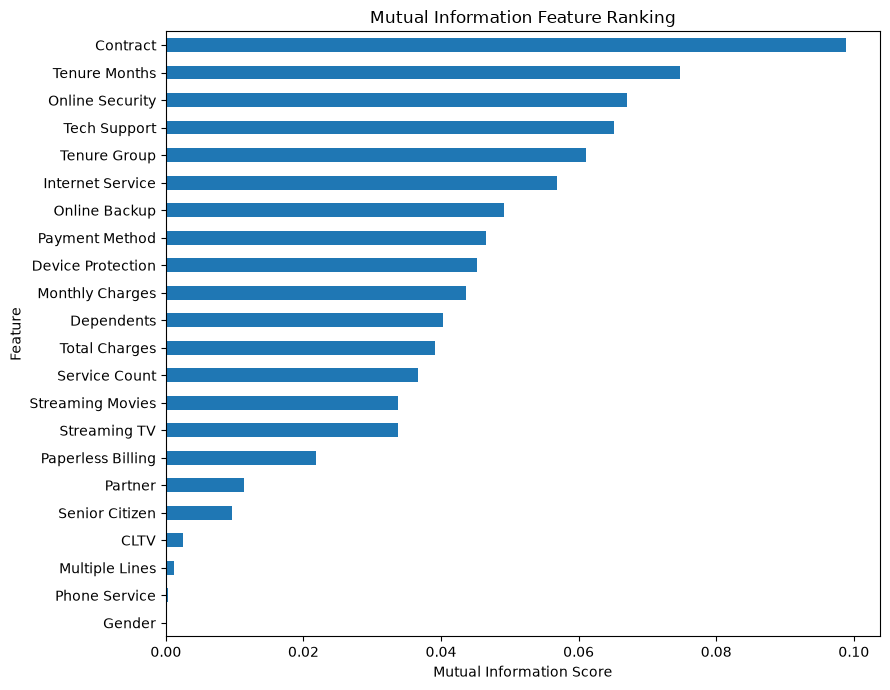

In [73]:
import matplotlib.pyplot as plt

mi_ranking.sort_values().plot(
    kind="barh",
    figsize=(9, 7),
    title="Mutual Information Feature Ranking"
)

plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [74]:
# Candidate feature sets
feature_sets = {
    "Top 10 MI": mi_ranking.head(10).index.tolist(),
    "Top 15 MI": mi_ranking.head(15).index.tolist(),
    "All 22 Features": X_train.columns.tolist()
}

# Candidate models
model_factories = {
    "Balanced Logistic Regression": lambda: LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),
    "Tuned Gradient Boosting": lambda: clone(
        best_gb.named_steps["classifier"]
    )
}

results = []

for feature_set_name, selected_features in feature_sets.items():

    X_train_selected = X_train[selected_features]
    X_val_selected = X_val[selected_features]

    numeric_cols = X_train_selected.select_dtypes(
        include="number"
    ).columns.tolist()

    categorical_cols = [
        col for col in X_train_selected.columns
        if col not in numeric_cols
    ]

    preprocessor_fs = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            (
                "cat",
                OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore"
                ),
                categorical_cols
            )
        ]
    )

    for model_name, model_factory in model_factories.items():

        experiment = Pipeline(
            steps=[
                ("preprocessor", clone(preprocessor_fs)),
                ("classifier", model_factory())
            ]
        )

        experiment.fit(X_train_selected, y_train)

        predictions = experiment.predict(X_val_selected)
        probabilities = experiment.predict_proba(X_val_selected)[:, 1]

        results.append({
            "Feature Set": feature_set_name,
            "Model": model_name,
            "Number of Features": len(selected_features),
            "Accuracy": accuracy_score(y_val, predictions),
            "Precision": precision_score(
                y_val, predictions, zero_division=0
            ),
            "Recall": recall_score(
                y_val, predictions, zero_division=0
            ),
            "F1": f1_score(
                y_val, predictions, zero_division=0
            ),
            "ROC-AUC": roc_auc_score(y_val, probabilities),
            "PR-AUC": average_precision_score(y_val, probabilities)
        })

feature_selection_results = pd.DataFrame(results)

feature_selection_results.sort_values(
    ["Model", "F1"],
    ascending=[True, False]
).round(3)

,Feature Set,Model,Number of Features,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
4,All 22 Features,Balanced Logistic Regression,22,0.746,0.513,0.821,0.632,0.850,0.640
2,Top 15 MI,Balanced Logistic Regression,15,0.744,0.511,0.804,0.625,0.850,0.637
0,Top 10 MI,Balanced Logistic Regression,10,0.740,0.506,0.814,0.624,0.844,0.640
5,All 22 Features,Tuned Gradient Boosting,22,0.810,0.670,0.557,0.608,0.853,0.659
3,Top 15 MI,Tuned Gradient Boosting,15,0.801,0.642,0.564,0.601,0.850,0.659
1,Top 10 MI,Tuned Gradient Boosting,10,0.797,0.649,0.514,0.574,0.849,0.655


#### With All 22 Features the model accuracy is slightly high, so we wont remove any features as of now.

### Training with XGboost

In [76]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("classifier", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgb_pipeline.fit(X_train, y_train)

print("XGBoost training completed.")

XGBoost training completed.


In [77]:
xgb_val_pred = xgb_pipeline.predict(X_val)
xgb_val_proba = xgb_pipeline.predict_proba(X_val)[:, 1]

print("Accuracy:", accuracy_score(y_val, xgb_val_pred))
print("Precision:", precision_score(y_val, xgb_val_pred, zero_division=0))
print("Recall:", recall_score(y_val, xgb_val_pred, zero_division=0))
print("F1:", f1_score(y_val, xgb_val_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_val, xgb_val_proba))
print("PR-AUC:", average_precision_score(y_val, xgb_val_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, xgb_val_pred))

Accuracy: 0.7859848484848485
Precision: 0.6062992125984252
Recall: 0.55
F1: 0.5767790262172284
ROC-AUC: 0.8476574005891016
PR-AUC: 0.6421056446839636

Confusion Matrix:
 [[676 100]
 [126 154]]


### Tuning XGboost

In [78]:
xgb_estimator = clone(xgb_pipeline)
xgb_estimator.set_params(classifier__n_jobs=1)

param_distributions = {
    "classifier__n_estimators": [200, 300, 500],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__max_depth": [2, 3, 4],
    "classifier__min_child_weight": [1, 3, 5],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0],
    "classifier__reg_lambda": [1, 5, 10],
    "classifier__scale_pos_weight": [1, 2, 3]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_estimator,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Best parameters:", xgb_search.best_params_)
print("Best CV PR-AUC:", xgb_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'classifier__subsample': 1.0, 'classifier__scale_pos_weight': 1, 'classifier__reg_lambda': 10, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 5, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}
Best CV PR-AUC: 0.6927163418360027


In [79]:
best_xgb = xgb_search.best_estimator_

xgb_tuned_pred = best_xgb.predict(X_val)
xgb_tuned_proba = best_xgb.predict_proba(X_val)[:, 1]

print("Accuracy:", accuracy_score(y_val, xgb_tuned_pred))
print("Precision:", precision_score(y_val, xgb_tuned_pred, zero_division=0))
print("Recall:", recall_score(y_val, xgb_tuned_pred, zero_division=0))
print("F1:", f1_score(y_val, xgb_tuned_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_val, xgb_tuned_proba))
print("PR-AUC:", average_precision_score(y_val, xgb_tuned_proba))

Accuracy: 0.8001893939393939
Precision: 0.6342412451361867
Recall: 0.5821428571428572
F1: 0.6070763500931099
ROC-AUC: 0.8530421575846833
PR-AUC: 0.6539691402559746


In [80]:
### Thershold optimization for XGBoost
candidates = {
    "Balanced Logistic Regression": balanced_lr,
    "Tuned Gradient Boosting": best_gb,
    "Tuned XGBoost": best_xgb
}

thresholds = np.arange(0.20, 0.71, 0.05)
threshold_results = []

for model_name, model in candidates.items():
    probabilities = model.predict_proba(X_val)[:, 1]

    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)

        threshold_results.append({
            "Model": model_name,
            "Threshold": round(threshold, 2),
            "Precision": precision_score(y_val, predictions, zero_division=0),
            "Recall": recall_score(y_val, predictions, zero_division=0),
            "F1": f1_score(y_val, predictions, zero_division=0),
            "F2": fbeta_score(y_val, predictions, beta=2, zero_division=0),
            "Predicted Churners": int(predictions.sum())
        })

threshold_df = pd.DataFrame(threshold_results)

best_thresholds = threshold_df.loc[
    threshold_df.groupby("Model")["F2"].idxmax()
].sort_values("F2", ascending=False)

best_thresholds.round(3)

,Model,Threshold,Precision,Recall,F1,F2,Predicted Churners
1,Balanced Logistic Regression,0.25,0.424,0.954,0.587,0.763,629
22,Tuned XGBoost,0.20,0.480,0.879,0.621,0.754,512
11,Tuned Gradient Boosting,0.20,0.478,0.879,0.619,0.752,515


### Confirming and saving the balanced logistic regression

In [81]:
from pathlib import Path

# Combine training and validation data
X_dev = pd.concat([X_train, X_val])
y_dev = pd.concat([y_train, y_val])

# Train the selected final model
final_model = clone(balanced_lr)
final_model.fit(X_dev, y_dev)

# Create the model artifact
model_artifact = {
    "pipeline": final_model,
    "threshold": 0.25,
    "feature_columns": X_dev.columns.tolist(),
    "model_name": "Balanced Logistic Regression"
}

# Resolve the correct project path
model_path = Path("../models/final_churn_model.joblib").resolve()
model_path.parent.mkdir(parents=True, exist_ok=True)

# Save the artifact
joblib.dump(model_artifact, model_path)

print("Saved path:", model_path)
print("File size:", model_path.stat().st_size, "bytes")

Saved path: C:\Users\Varunreddy\OneDrive\Desktop\customer_churn_ml\models\final_churn_model.joblib
File size: 8709 bytes


In [82]:
saved_artifact = joblib.load(model_path)

print("Model:", saved_artifact["model_name"])
print("Threshold:", saved_artifact["threshold"])
print("Number of features:", len(saved_artifact["feature_columns"]))

# Verify that the saved model can generate probabilities
sample_probabilities = (
    saved_artifact["pipeline"]
    .predict_proba(X_dev.head(2))[:, 1]
)

print("Sample probabilities:", sample_probabilities)

Model: Balanced Logistic Regression
Threshold: 0.25
Number of features: 22
Sample probabilities: [0.85974956 0.89623767]
